# 04 - Évaluation et export

Deux choses, dans l'ordre : évaluer le modèle Keras entraîné sur le test, une fois pour toutes (accuracy, matrice de confusion, F1 macro), puis exporter ce modèle figé en TensorFlow Lite (float32 et int8), en vérifiant que les deux versions restent proches du modèle Keras d'origine.

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

DATA_DIR = Path("../data/raw/UCI HAR Dataset")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

I0000 00:00:1790198172.844208   28250 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790198172.844764   28250 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790198172.884826   28250 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790198174.007483   28250 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790198174.007949   28250 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Recharger le modèle figé, la normalisation et le test

In [2]:
with open(MODELS_DIR / "normalization.json") as f:
    normalization = json.load(f)
with open(MODELS_DIR / "labels.json") as f:
    labels_map = json.load(f)

CHANNELS = normalization["channels"]
mean = np.array(normalization["mean"])
std = np.array(normalization["std"])
validation_subjects = normalization["validation_subjects"]
label_names = [labels_map[str(i)] for i in range(len(labels_map))]

def load_ids(path):
    return pd.read_csv(path, header=None, names=["value"]).squeeze("columns")

def load_signal(split, signal_name):
    path = DATA_DIR / split / "Inertial Signals" / f"{signal_name}_{split}.txt"
    return np.loadtxt(path)

def load_windows(split):
    signals = [load_signal(split, name) for name in CHANNELS]
    return np.stack(signals, axis=-1)

def normalize(X):
    return (X - mean) / std

X_train_full = load_windows("train")
subject_train_full = load_ids(DATA_DIR / "train" / "subject_train.txt")
fit_mask = ~subject_train_full.isin(validation_subjects).to_numpy()
X_fit = normalize(X_train_full[fit_mask]).astype("float32")

X_test = normalize(load_windows("test")).astype("float32")
y_test = (load_ids(DATA_DIR / "test" / "y_test.txt") - 1).to_numpy()

model = tf.keras.models.load_model(MODELS_DIR / "model.keras")
print("test set:", X_test.shape)

test set: (2947, 128, 9)


E0000 00:00:1790198177.311063   28250 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Évaluation du modèle Keras sur le test

In [3]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = (y_pred == y_test).mean()
report = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
macro_f1 = report["macro avg"]["f1-score"]

print(f"accuracy: {test_accuracy:.3f}")
print(f"macro F1: {macro_f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=label_names))

accuracy: 0.893
macro F1: 0.893

                    precision    recall  f1-score   support

           WALKING       0.99      0.94      0.96       496
  WALKING_UPSTAIRS       0.89      0.94      0.92       471
WALKING_DOWNSTAIRS       0.87      0.91      0.89       420
           SITTING       0.82      0.76      0.79       491
          STANDING       0.80      0.84      0.82       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.89      2947
         macro avg       0.89      0.89      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



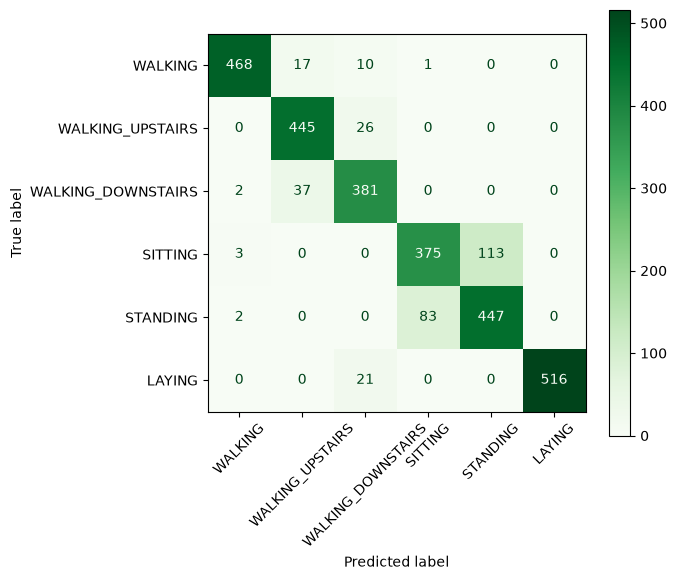

In [4]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, cmap="Greens")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png")
plt.show()

## Analyse des confusions

La confusion la plus importante est **SITTING / STANDING** : 113 fenêtres "assis" prédites "debout", 83 dans l'autre sens. Cohérent avec l'exploration : ces deux activités ont une amplitude de signal presque identique (~0.92g contre ~1.02g), et l'accéléromètre à la taille ne voit presque aucune différence entre les deux postures statiques.

Deuxième confusion notable : **WALKING_UPSTAIRS / WALKING_DOWNSTAIRS** (26 + 37 fenêtres). Les deux produisent une oscillation périodique similaire, la direction verticale étant plus subtile à capter que le fait de marcher sur des marches.

**LAYING** est presque parfait (recall 0.96, precision 1.00) : allongé, l'orientation du capteur par rapport à la gravité change complètement.

## Export TensorFlow Lite (float32)

Conversion directe, sans quantification : mêmes poids que le modèle Keras, dans un format plus compact, pensé pour l'inférence sur appareil restreint.

In [5]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float32 = converter.convert()

path_float32 = MODELS_DIR / "model_float32.tflite"
path_float32.write_bytes(tflite_float32)
print(f"{path_float32.name}: {path_float32.stat().st_size / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpd_xyjl66/assets


INFO:tensorflow:Assets written to: /tmp/tmpd_xyjl66/assets


Saved artifact at '/tmp/tmpd_xyjl66'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 9), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  126471230687376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230687952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230687760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230686608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230691792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230694096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692560: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1790198178.411704   28250 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790198178.411732   28250 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


model_float32.tflite: 36.3 KB


I0000 00:00:1790198178.412263   28250 reader.cc:83] Reading SavedModel from: /tmp/tmpd_xyjl66
I0000 00:00:1790198178.412629   28250 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790198178.412636   28250 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpd_xyjl66
I0000 00:00:1790198178.418021   28250 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790198178.418754   28250 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790198178.457806   28250 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpd_xyjl66
I0000 00:00:1790198178.468233   28250 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 55986 microseconds.
I0000 00:00:1790198178.498114   28250 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


## Export TensorFlow Lite (int8, quantification complète)

Ici les poids et les activations sont convertis en entiers 8 bits : ça réduit fortement la taille et accélère l'inférence, notamment via des noyaux optimisés comme ESP-NN. Il faut fournir un `representative_dataset` : un échantillon des données d'entraînement déjà normalisées, que le convertisseur utilise pour estimer la plage de valeurs à quantifier.

In [6]:
def representative_dataset():
    rng = np.random.default_rng(42)
    indices = rng.choice(len(X_fit), size=200, replace=False)
    for i in indices:
        yield [X_fit[i:i+1]]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8
tflite_int8 = converter_int8.convert()

path_int8 = MODELS_DIR / "model_int8.tflite"
path_int8.write_bytes(tflite_int8)
print(f"{path_int8.name}: {path_int8.stat().st_size / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpn2o6cu7r/assets


INFO:tensorflow:Assets written to: /tmp/tmpn2o6cu7r/assets


Saved artifact at '/tmp/tmpn2o6cu7r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 9), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  126471230687376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230687952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230687760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230686608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230691792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230694096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126471230692560: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/bogdan/dev/school/rattrappage/m2-rattrapages-monote-bogdan/02-IoT-Intelligence-Artificielle/venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1790198178.875921   28250 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790198178.875938   28250 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790198178.876063   28250 reader.cc:83] Reading SavedModel from: /tmp/tmpn2o6cu7r
I0000 00:00:1790198178.876445   28250 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790198178.876450   28250 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpn2o6cu7r
I0000 00:00:1790198178.879806   28250 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790198178.908283   28250 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpn2o6cu7r
I0

model_int8.tflite: 17.7 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1790198179.026994   28250 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


## Vérifier les deux versions .tflite sur le test

Le modèle int8 attend des entrées entières : il faut les quantifier nous-même avec le `scale` et le `zero_point` lus dans `get_input_details()` (`valeur_entière = valeur_réelle / scale + zero_point`), puis déquantifier la sortie de la même façon pour retrouver des probabilités comparables.

In [7]:
def evaluate_tflite(tflite_model, X, y, quantized_io):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    predictions = np.zeros(len(X), dtype="int64")
    for i in range(len(X)):
        sample = X[i:i+1]
        if quantized_io:
            scale, zero_point = input_details["quantization"]
            sample = np.round(sample / scale + zero_point).astype(input_details["dtype"])
        interpreter.set_tensor(input_details["index"], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]
        predictions[i] = np.argmax(output)
    accuracy = (predictions == y).mean()
    f1 = classification_report(y, predictions, target_names=label_names, output_dict=True)["macro avg"]["f1-score"]
    return accuracy, f1

accuracy_float32, f1_float32 = evaluate_tflite(tflite_float32, X_test, y_test, quantized_io=False)
accuracy_int8, f1_int8 = evaluate_tflite(tflite_int8, X_test, y_test, quantized_io=True)

print(f"tflite float32 -> accuracy {accuracy_float32:.3f}, macro F1 {f1_float32:.3f}")
print(f"tflite int8    -> accuracy {accuracy_int8:.3f}, macro F1 {f1_int8:.3f}")

tflite float32 -> accuracy 0.893, macro F1 0.893
tflite int8    -> accuracy 0.893, macro F1 0.893


/home/bogdan/dev/school/rattrappage/m2-rattrapages-monote-bogdan/02-IoT-Intelligence-Artificielle/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/home/bogdan/dev/school/rattrappage/m2-rattrapages-monote-bogdan/02-IoT-Intelligence-Artificielle/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warni

## Tableau comparatif et sauvegarde des métriques

In [8]:
comparison = {
    "keras": {
        "size_kb": (MODELS_DIR / "model.keras").stat().st_size / 1024,
        "accuracy": float(test_accuracy),
        "macro_f1": float(macro_f1),
    },
    "tflite_float32": {
        "size_kb": path_float32.stat().st_size / 1024,
        "accuracy": float(accuracy_float32),
        "macro_f1": float(f1_float32),
    },
    "tflite_int8": {
        "size_kb": path_int8.stat().st_size / 1024,
        "accuracy": float(accuracy_int8),
        "macro_f1": float(f1_int8),
    },
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(comparison, f, indent=2)

pd.DataFrame(comparison).T

,size_kb,accuracy,macro_f1
keras,131.997070,0.893112,0.892967
tflite_float32,36.316406,0.893112,0.892967
tflite_int8,17.726562,0.892772,0.892594


## Observations

- **Accuracy test 0.893, F1 macro 0.893** : très proches, cohérent avec des classes pas extrêmement déséquilibrées.
- **Tailles :** `model.keras` 132 Ko, `model_float32.tflite` 36.3 Ko, `model_int8.tflite` 17.7 Ko. Le format Keras stocke aussi la config de l'optimiseur, inutile pour l'inférence ; la quantification int8 divise encore par 2 environ.
- **Coût de la quantification : quasi nul.** Accuracy 0.8931 → 0.8928, F1 macro 0.8930 → 0.8926, une perte de 0.0004. Taille divisée par plus de 7 par rapport au format Keras, pour une précision quasi identique.
- `model_int8.tflite` est la version utilisée dans la simulation IoT, la seule vraiment pertinente pour un microcontrôleur.